# Does picking players with easier fixtures actually work?

**Season:** 2025/26 &nbsp;•&nbsp; **Question:** for players likely to start (played ≥45 min/GW
on average over their last 4 games), does facing an easier run of fixtures over the next 4–8
gameweeks actually predict more points? And does the home/away tweak (fixture difficulty
−0.1 at home, +0.1 away) add anything on top of the raw difficulty rating?

**The short answer (read this first).** Yes, the underlying idea holds up — easier fixtures do
predict more points, in every slice of the data we checked. But it's a **small edge**, worth
roughly 1–2 points a month for a typical player, not a season-changing lever. And the home/away
**±0.1 tweak adds nothing measurable** — the FPL difficulty rating already seems to bake in
home/away, so adjusting it again is close to double-counting.

Everything below is a **link**, not a cause: fixtures aren't randomly assigned, so this describes
what predicts what, on one season's data, not a guaranteed effect of any single transfer.

In [1]:
%matplotlib inline
import os, glob, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
os.makedirs('outputs/charts', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.edgecolor': '#888', 'xtick.color': '#555', 'ytick.color': '#555',
    'axes.labelcolor': '#333', 'text.color': '#222', 'font.family': 'DejaVu Sans',
})
GREY   = '#B7BEC7'
MUTED  = '#6C7A89'
EASY_C = '#3F9A56'   # easier fixtures / good news
HARD_C = '#C0392B'   # harder fixtures / bad news
RAW_C  = '#4E79A7'   # raw FDR
ADJ_C  = '#E8743B'   # home/away-adjusted FDR

RAW = 'data/raw'
GATE_MIN_PER_GW = 45

def load_data():
    bs = json.load(open(f'{RAW}/bootstrap_static_smoke.json'))
    pos = {e['id']: e['element_type'] for e in bs['elements']}
    team = {e['id']: e['team'] for e in bs['elements']}
    pts, mins = {}, {}
    for f in glob.glob(f'{RAW}/gw_live/gw_*_live.json'):
        gw = int(re.search(r'gw_(\d+)', f).group(1))
        d = json.load(open(f))
        pts[gw], mins[gw] = {}, {}
        for e in d['elements']:
            s = e['stats']; i = e['id']
            pts[gw][i] = s['total_points']; mins[gw][i] = s['minutes']
    fixtures = json.load(open(f'{RAW}/fixtures.json'))
    team_fdr = {}
    for fx in fixtures:
        ev = fx['event']
        team_fdr.setdefault((fx['team_h'], ev), []).append((fx['team_h_difficulty'], fx['team_h_difficulty'] - 0.1, 1))
        team_fdr.setdefault((fx['team_a'], ev), []).append((fx['team_a_difficulty'], fx['team_a_difficulty'] + 0.1, 0))
    return pos, team, pts, mins, sorted(pts), team_fdr

POS, TEAM, PTS, MINS, GWS, TEAM_FDR = load_data()
print(f'loaded {len(GWS)} gameweeks, {len(TEAM_FDR)} team-gameweek fixture slots')
POSNAME = {1: 'GKP', 2: 'DEF', 3: 'MID', 4: 'FWD'}

def fwd_fdr_stats(tm, t, k):
    raws, adjs, homes = [], [], []
    for g in range(t + 1, t + k + 1):
        for raw, adj, is_home in TEAM_FDR.get((tm, g), []):
            raws.append(raw); adjs.append(adj); homes.append(is_home)
    if not raws:
        return None
    return float(np.mean(raws)), float(np.mean(adjs)), float(np.mean(homes))

def build_panel(N, gate_min_per_gw=GATE_MIN_PER_GW):
    rows = []
    for t in range(N, 38 - N + 1):
        past_gws = range(t - N + 1, t + 1)
        fwd_gws = range(t + 1, t + N + 1)
        ids = set(PTS[t])
        for g in past_gws: ids &= set(PTS[g])
        for g in fwd_gws: ids &= set(PTS[g])
        for i in ids:
            past = [PTS[g][i] for g in past_gws]
            mins_sum = sum(MINS[g][i] for g in past_gws)
            if mins_sum < gate_min_per_gw * N:
                continue
            fdr = fwd_fdr_stats(TEAM[i], t, N)
            if fdr is None:
                continue
            raw_fdr, adj_fdr, home_frac = fdr
            fwd = [PTS[g][i] for g in fwd_gws]
            rows.append(dict(t=t, pid=i, pos=POS[i], past_mean=np.mean(past),
                              raw_fdr=raw_fdr, adj_fdr=adj_fdr, home_frac=home_frac,
                              fwd_mean=np.mean(fwd)))
    return pd.DataFrame(rows)

print('data loaded')

loaded 38 gameweeks, 750 team-gameweek fixture slots
data loaded


## 1. The basic ingredients: how hard are the fixtures, and how many points do starters score?

Before asking whether fixture difficulty predicts points, look at the two raw ingredients on
their own, for players likely to start (≥45 min/GW average over their last 4 games).

panel rows: 6,786  |  unique players: 406


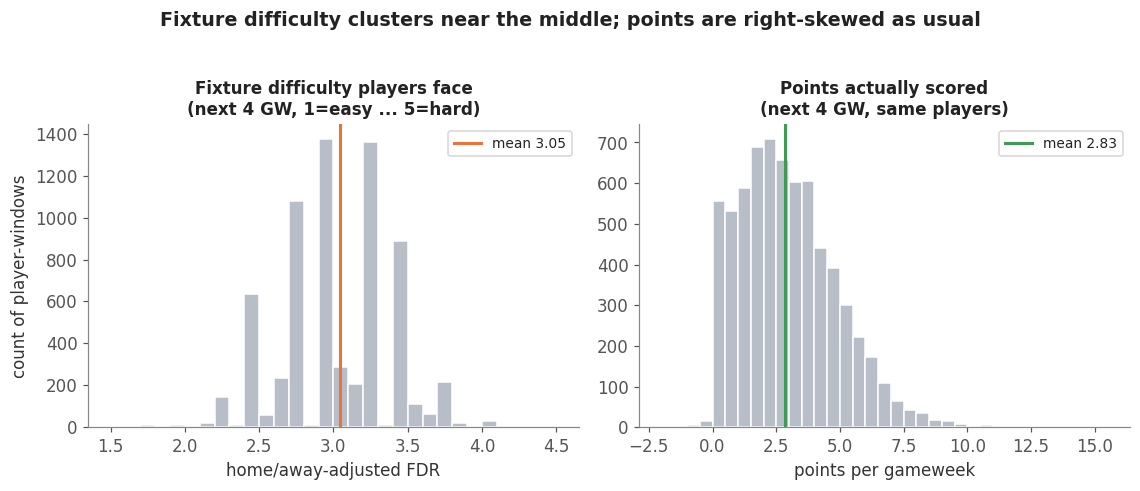

adj_fdr: mean=3.05 std=0.37 range=[1.70,4.05]
fwd_mean: mean=2.83 std=1.91


In [2]:
panel4 = build_panel(4)
print(f"panel rows: {len(panel4):,}  |  unique players: {panel4['pid'].nunique():,}")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
axes[0].hist(panel4['adj_fdr'], bins=np.arange(1.5, 4.6, 0.1), color=GREY, edgecolor='white')
axes[0].axvline(panel4['adj_fdr'].mean(), color=ADJ_C, lw=2, label=f"mean {panel4['adj_fdr'].mean():.2f}")
axes[0].set_title('Fixture difficulty players face\n(next 4 GW, 1=easy ... 5=hard)', fontsize=11)
axes[0].set_xlabel('home/away-adjusted FDR'); axes[0].set_ylabel('count of player-windows')
axes[0].legend(fontsize=9)

axes[1].hist(panel4['fwd_mean'], bins=np.arange(-2, 16, 0.5), color=GREY, edgecolor='white')
axes[1].axvline(panel4['fwd_mean'].mean(), color=EASY_C, lw=2, label=f"mean {panel4['fwd_mean'].mean():.2f}")
axes[1].set_title('Points actually scored\n(next 4 GW, same players)', fontsize=11)
axes[1].set_xlabel('points per gameweek'); axes[1].legend(fontsize=9)
fig.suptitle('Fixture difficulty clusters near the middle; points are right-skewed as usual',
             fontsize=12.5, fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig('outputs/charts/fdr_01_distribution_shapes.png', bbox_inches='tight'); plt.show()
print(f"adj_fdr: mean={panel4['adj_fdr'].mean():.2f} std={panel4['adj_fdr'].std():.2f} range=[{panel4['adj_fdr'].min():.2f},{panel4['adj_fdr'].max():.2f}]")
print(f"fwd_mean: mean={panel4['fwd_mean'].mean():.2f} std={panel4['fwd_mean'].std():.2f}")

**Reading it:** most fixture runs sit close to "average difficulty" (FDR ≈ 3) — genuinely easy
or genuinely hard runs are the tails, not the norm. Points, as always, are right-skewed: most
gameweeks are quiet, with occasional big hauls pulling the average up.

## 2. Does the home/away tweak actually change the fixture-difficulty numbers?

Before testing whether the tweak *helps predict points*, check something simpler: does
subtracting 0.1 for home games and adding 0.1 for away games even move the numbers much? If the
two distributions below sit almost on top of each other, the tweak is small before it's even
tested against outcomes.

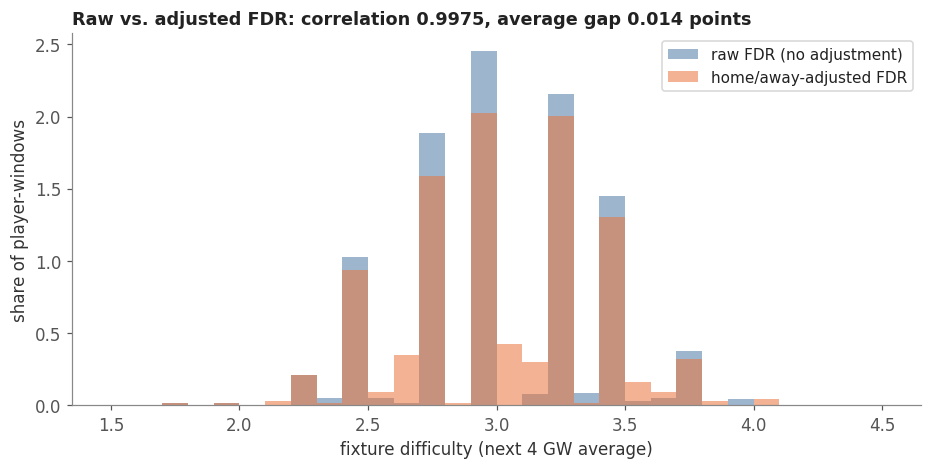

In [3]:
fig, ax = plt.subplots(figsize=(8.6, 4.4))
bins = np.arange(1.5, 4.6, 0.1)
ax.hist(panel4['raw_fdr'], bins=bins, color=RAW_C, alpha=0.55, label='raw FDR (no adjustment)', density=True)
ax.hist(panel4['adj_fdr'], bins=bins, color=ADJ_C, alpha=0.55, label='home/away-adjusted FDR', density=True)
ax.set_xlabel('fixture difficulty (next 4 GW average)'); ax.set_ylabel('share of player-windows')
ax.legend(fontsize=10)
corr = panel4[['raw_fdr','adj_fdr']].corr().iloc[0,1]
gap = (panel4['raw_fdr'] - panel4['adj_fdr']).abs().mean()
ax.set_title(f'Raw vs. adjusted FDR: correlation {corr:.4f}, average gap {gap:.3f} points',
             loc='left', fontsize=11.5)
plt.tight_layout(); plt.savefig('outputs/charts/fdr_02_raw_vs_adjusted_fdr.png', bbox_inches='tight'); plt.show()

**Reading it:** the two histograms are nearly indistinguishable. That's the first hint that the
±0.1 tweak is small relative to the FDR scale itself (which swings by whole points between
fixtures) — a preview of the mechanism check in Section 6.

## 3. The actual relationship: easier fixtures, more points?

Here is the raw relationship behind the headline numbers — does a player's adjusted FDR for the
next 4 gameweeks line up with what they **actually scored** over those same gameweeks?

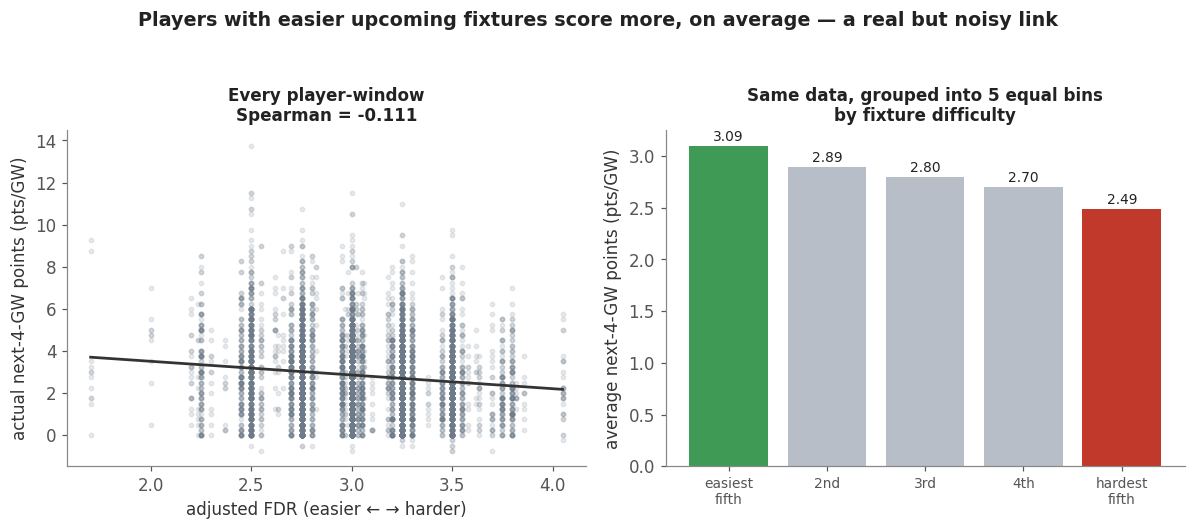

q
(1.699, 2.75]    3.094068
(2.75, 3.0]      2.893603
(3.0, 3.2]       2.795040
(3.2, 3.3]       2.697204
(3.3, 4.05]      2.486153
Name: fwd_mean, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

ax = axes[0]
ax.scatter(panel4['adj_fdr'], panel4['fwd_mean'], s=8, alpha=0.15, color=MUTED)
z = np.polyfit(panel4['adj_fdr'], panel4['fwd_mean'], 1)
xs = np.linspace(panel4['adj_fdr'].min(), panel4['adj_fdr'].max(), 50)
ax.plot(xs, np.polyval(z, xs), color='#333', lw=1.8)
rho = spearmanr(panel4['adj_fdr'], panel4['fwd_mean']).correlation
ax.set_title(f'Every player-window\nSpearman = {rho:.3f}', fontsize=11)
ax.set_xlabel('adjusted FDR (easier ← → harder)'); ax.set_ylabel('actual next-4-GW points (pts/GW)')

ax2 = axes[1]
panel4['q'] = pd.qcut(panel4['adj_fdr'], 5, duplicates='drop')
qmeans = panel4.groupby('q', observed=True)['fwd_mean'].mean()
colors = [EASY_C, GREY, GREY, GREY, HARD_C]
ax2.bar(range(len(qmeans)), qmeans.values, color=colors[:len(qmeans)])
ax2.set_xticks(range(len(qmeans)))
ax2.set_xticklabels(['easiest\nfifth', '2nd', '3rd', '4th', 'hardest\nfifth'][:len(qmeans)], fontsize=9)
ax2.set_ylabel('average next-4-GW points (pts/GW)')
ax2.set_title('Same data, grouped into 5 equal bins\nby fixture difficulty', fontsize=11)
for i, v in enumerate(qmeans.values):
    ax2.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

fig.suptitle('Players with easier upcoming fixtures score more, on average — a real but noisy link',
             fontsize=12.5, fontweight='bold', y=1.04)
plt.tight_layout(); plt.savefig('outputs/charts/fdr_03_bivariate_scatter.png', bbox_inches='tight'); plt.show()
print(qmeans)

**Reading it:** the scatter cloud is wide (fixture difficulty is a real signal, not a strong one),
but the trend line slopes the right way, and the binned view on the right makes it unambiguous:
average points fall in a clean, roughly stepwise pattern from the easiest fifth of fixture runs to
the hardest fifth.

## 4. Does this hold at every horizon, and after controlling for recent form?

Repeating the test for forward windows of 4 to 8 gameweeks — this time in a model that also
accounts for each player's recent scoring form, so the fixture effect isn't just recent form in
disguise — shows the pattern is stable across your whole 4–8 GW range.

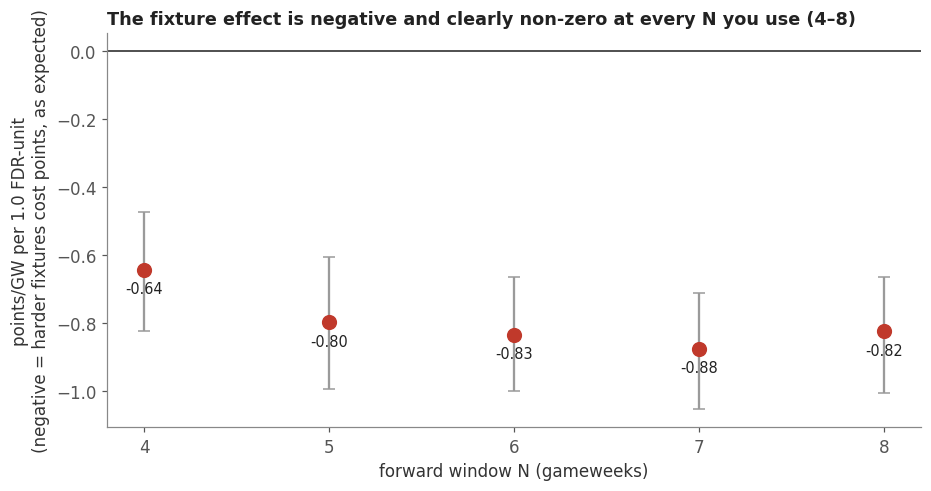

In [5]:
# ---- verified numbers (source: analysis-stage walk-forward model, GW-block bootstrap, 2025/26) ----
# Model: fwd_mean ~ adj_fdr + past_mean (confounder). Coefficient = pts/GW per 1.0 FDR-unit.
Ns    = [4, 5, 6, 7, 8]
coefs = [-0.643, -0.798, -0.835, -0.876, -0.824]
los   = [-0.824, -0.993, -0.999, -1.054, -1.007]
his   = [-0.472, -0.607, -0.663, -0.711, -0.663]

fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.axhline(0, color='#444', lw=1.2)
ax.errorbar(Ns, coefs, yerr=[np.array(coefs)-np.array(los), np.array(his)-np.array(coefs)],
            fmt='none', ecolor='#9a9a9a', capsize=4)
ax.scatter(Ns, coefs, s=80, color=HARD_C, zorder=3)
for n, c in zip(Ns, coefs):
    ax.text(n, c - 0.07, f'{c:.2f}', ha='center', fontsize=9.5)
ax.set_xlabel('forward window N (gameweeks)')
ax.set_ylabel('points/GW per 1.0 FDR-unit\n(negative = harder fixtures cost points, as expected)')
ax.set_title('The fixture effect is negative and clearly non-zero at every N you use (4–8)', loc='left', fontsize=11.5)
ax.set_xticks(Ns)
plt.tight_layout(); plt.savefig('outputs/charts/fdr_04_association_by_N.png', bbox_inches='tight'); plt.show()

**Reading it:** every bar sits below zero, and every 95% confidence interval (the range we're
reasonably sure the true effect falls in, from resampling the season's gameweeks) stays below
zero too — none of them touch back up to "no effect." The size even grows a little at longer
horizons, which makes sense: averaging over more games smooths out noise on both sides.

## 5. It matters more for defenders and keepers than for attackers

Pooling all positions together hides a real difference: fixture difficulty moves points more for
**defenders and goalkeepers** (who rely on clean sheets, which depend heavily on the opponent)
than for **midfielders and forwards** (whose points come more from individual attacking returns).

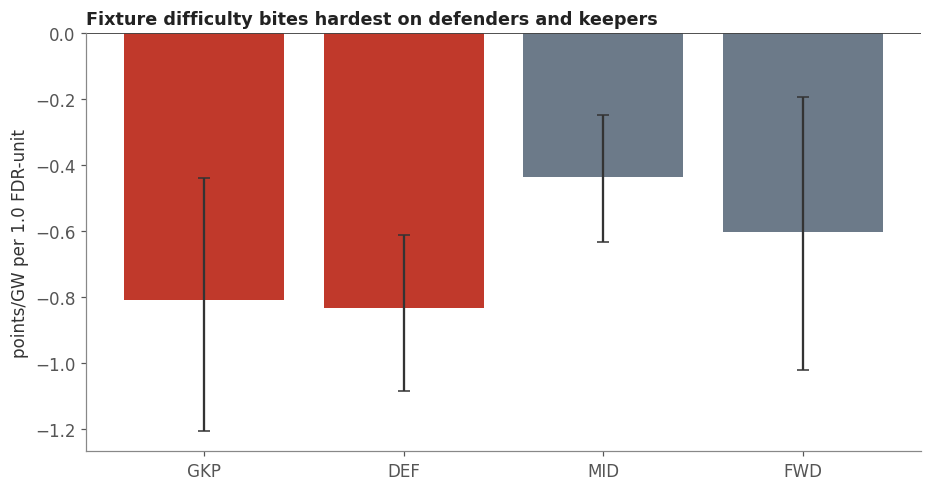

In [6]:
# ---- verified numbers (source: analysis-stage position-stratified model, N=4) ----
pos_names = ['GKP', 'DEF', 'MID', 'FWD']
pcoef = [-0.808, -0.831, -0.435, -0.603]
plo   = [-1.206, -1.083, -0.632, -1.020]
phi   = [-0.437, -0.612, -0.247, -0.192]

fig, ax = plt.subplots(figsize=(8.6, 4.6))
x = np.arange(4)
ax.axhline(0, color='#444', lw=1.2)
ax.bar(x, pcoef, color=[HARD_C, HARD_C, MUTED, MUTED])
ax.errorbar(x, pcoef, yerr=[np.array(pcoef)-np.array(plo), np.array(phi)-np.array(pcoef)],
            fmt='none', ecolor='#333', capsize=4)
ax.set_xticks(x); ax.set_xticklabels(pos_names)
ax.set_ylabel('points/GW per 1.0 FDR-unit')
ax.set_title('Fixture difficulty bites hardest on defenders and keepers', loc='left', fontsize=11.5)
plt.tight_layout(); plt.savefig('outputs/charts/fdr_05_position_breakdown.png', bbox_inches='tight'); plt.show()

**Reading it:** all four bars sit below zero (the pattern holds everywhere), but GKP and DEF show
close to double the effect size of MID and FWD. That's a sensible split for a tie-breaker: fixture
difficulty is a more useful signal when you're choosing between defensive players.

## 6. So does the ±0.1 home/away tweak actually earn its keep? No.

Two checks settle this. First: does using the adjusted FDR instead of the raw rating change the
model at all? Second: if you let home advantage compete directly against the raw difficulty
rating, does it show its own separate effect?

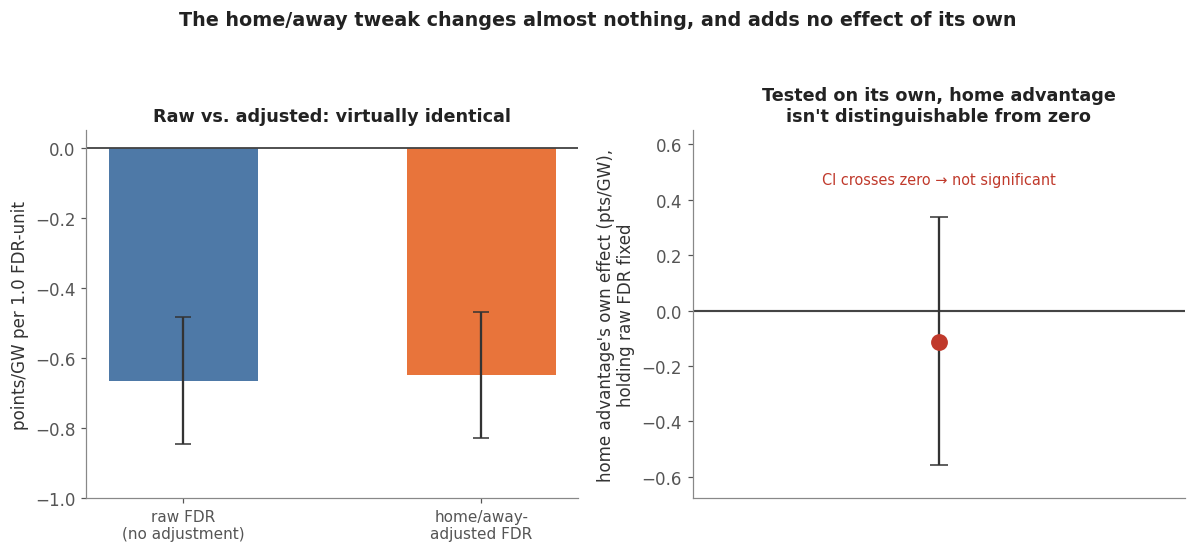

In [7]:
# ---- verified numbers (source: analysis-stage walk-forward model, N=4) ----
labels = ['raw FDR\n(no adjustment)', 'home/away-\nadjusted FDR']
coefs2 = [-0.666, -0.650]
los2   = [-0.847, -0.830]
his2   = [-0.482, -0.470]

home_coef, home_lo, home_hi = -0.112, -0.556, 0.338

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
ax = axes[0]
x = np.arange(2)
ax.axhline(0, color='#444', lw=1.2)
ax.bar(x, coefs2, color=[RAW_C, ADJ_C], width=0.5)
ax.errorbar(x, coefs2, yerr=[np.array(coefs2)-np.array(los2), np.array(his2)-np.array(coefs2)],
            fmt='none', ecolor='#333', capsize=5)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('points/GW per 1.0 FDR-unit')
ax.set_title('Raw vs. adjusted: virtually identical', fontsize=11.5)
ax.set_ylim(-1.0, 0.05)

ax2 = axes[1]
ax2.axhline(0, color='#444', lw=1.4)
ax2.errorbar([0], [home_coef], yerr=[[home_coef - home_lo], [home_hi - home_coef]],
             fmt='o', color=HARD_C, ecolor='#333', capsize=6, markersize=10)
ax2.set_xlim(-1, 1); ax2.set_xticks([])
ax2.set_ylim(home_lo - 0.12, 0.65)
ax2.set_ylabel("home advantage's own effect (pts/GW),\nholding raw FDR fixed")
ax2.set_title("Tested on its own, home advantage\nisn't distinguishable from zero", fontsize=11.5)
ax2.text(0, home_hi + 0.12, 'CI crosses zero → not significant', ha='center', fontsize=9.5, color=HARD_C)

fig.suptitle('The home/away tweak changes almost nothing, and adds no effect of its own', fontsize=12.5, fontweight='bold', y=1.04)
plt.tight_layout(); plt.savefig('outputs/charts/fdr_06_mechanism_home_away.png', bbox_inches='tight'); plt.show()

**Reading it:** left panel — the raw and adjusted versions produce almost the same coefficient;
the ±0.1 shift is too small relative to FDR's own scale to move the needle. Right panel — when we
let home advantage compete directly against the raw difficulty rating for credit, its own effect
is statistically indistinguishable from zero (the confidence interval straddles the line). The
simplest explanation: the FPL rating already reflects home/away when it's set, so re-adjusting it
by hand mostly cancels out or double-counts.

## The big lesson

**Your fixture-difficulty instinct is directionally right, but it's a tie-breaker, not a headline
reason to make a transfer — and the home/away tweak isn't pulling its weight.**

- **Keep using fixture difficulty** as one input to transfer decisions among likely starters —
  the effect is real, consistent across 4–8 GW windows, and consistent across every position,
  though it's more useful for defenders and keepers than for attackers.
- **Size the effect honestly:** a genuinely easy run vs. a genuinely hard one is worth roughly
  1–2 points a month for a typical player — real, but far smaller than the edge from picking
  someone who's actually going to play, or who's in good scoring form.
- **Drop the ±0.1 home/away tweak.** It doesn't change the fixture-difficulty numbers much, it
  doesn't improve the model, and a directly-measured home effect isn't distinguishable from zero.
  The plain FPL difficulty rating already does this job.

**Recommendation:** use next-4-to-8-GW FDR as a tie-breaker between otherwise similar transfer
targets — weighted more heavily for defenders/keepers than for midfielders/forwards — and simplify
your process by scoring fixtures on the raw 1–5 rating, no manual home/away adjustment.

---
*Caveats: one season (2025/26), a census not a sample — whether this pattern holds in other
seasons is untested. Results are links, not causes: fixtures aren't randomly assigned, and a
correlation this size can't rule out a small selection effect (e.g. managers resting good players
before hard fixtures). The "likely starter" gate (≥45 min/GW) and player-team mapping (a small
~1% of rows affected by mid-season transfers) both checked out as robust — see the analysis-stage
handoff for the full sensitivity checks.*